In [1]:
!pip install ultralytics

In [2]:
import os
import subprocess
import sys
from ultralytics import YOLO
from collections import deque
import cv2
import time
import numpy as np
from google.colab.patches import cv2_imshow

In [3]:
class CrowdPeopleDetector:
    """
    Детектор людей в толпе с использованием YOLOv8 и простым трекингом.

    Класс предоставляет функциональность для обнаружения и отслеживания людей
    на видео с использованием модели YOLOv8 и простого алгоритма трекинга
    на основе расстояния между центрами bounding box.

    Attributes:
        model_size (str): Размер модели YOLOv8 ('n', 's', 'm', 'l', 'x')
        model (YOLO): Загруженная модель YOLOv8
        confidence_threshold (float): Порог уверенности для детекции
        iou_threshold (float): Порог IoU для non-maximum suppression
        colors (list): Список цветов для визуализации треков
        people_count_history (deque): История количества людей по кадрам
        track_history (dict): История треков объектов
        next_track_id (int): Следующий ID для нового трека
    """

    def __init__(self, model_size='m'):
        """
        Инициализирует детектор людей в толпе.

        Args:
            model_size (str, optional): Размер модели YOLOv8.
                                      Доступны: 'n', 's', 'm', 'l', 'x'.
                                      По умолчанию 'm'.

        Raises:
            Exception: Если не удается загрузить модель YOLOv8
        """
        self.model_size = model_size
        self.model = None
        self.setup_model()

        self.confidence_threshold = 0.25
        self.iou_threshold = 0.45

        self.colors = [
            (255, 0, 0), (0, 255, 0), (0, 0, 255),
            (255, 255, 0), (255, 0, 255), (0, 255, 255),
            (128, 0, 0), (0, 128, 0), (0, 0, 128)
        ]

        self.people_count_history = deque(maxlen=30)
        self.track_history = {}
        self.next_track_id = 1

    def setup_model(self):
        """
        Загружает и инициализирует модель YOLOv8 для детекции объектов.

        Метод загружает предобученную модель YOLOv8 указанного размера
        и устанавливает ее как основную модель для детекции.

        Raises:
            Exception: Если происходит ошибка при загрузке модели
        """
        print("Загрузка YOLOv8 модели...")
        try:
            self.model = YOLO(f'yolov8{self.model_size}.pt')
            print(f"YOLOv8{self.model_size} модель загружена!")
        except Exception as e:
            print(f"Ошибка загрузки модели: {e}")
            raise

    def simple_tracker(self, detections, max_distance=50):
        """
        Реализует простой трекер для связывания детекций между кадрами.

        Алгоритм основан на сопоставлении детекций по минимальному расстоянию
        между центрами bounding box в последовательных кадрах.

        Args:
            detections (list): Список детекций в формате [x1, y1, x2, y2, conf, cls]
            max_distance (int, optional): Максимальное расстояние для сопоставления треков.
                                        По умолчанию 50 пикселей.

        Returns:
            dict: Словарь с текущими треками, где ключ - ID трека, значение - информация о треке
                  Формат: {track_id: {'bbox': (x1,y1,x2,y2), 'confidence': conf,
                          'positions': [(center_x, center_y), ...], 'color': color}}
        """
        current_tracks = {}

        for detection in detections:
            x1, y1, x2, y2, conf, cls = detection
            center_x = (x1 + x2) / 2
            center_y = (y1 + y2) / 2

            best_track_id = None
            min_distance = max_distance

            for track_id, track_info in self.track_history.items():
                last_center = track_info['positions'][-1]
                distance = np.sqrt((center_x - last_center[0])**2 + (center_y - last_center[1])**2)

                if distance < min_distance:
                    min_distance = distance
                    best_track_id = track_id

            if best_track_id is not None:
                current_tracks[best_track_id] = {
                    'bbox': (x1, y1, x2, y2),
                    'confidence': conf,
                    'positions': self.track_history[best_track_id]['positions'] + [(center_x, center_y)],
                    'color': self.track_history[best_track_id]['color']
                }
                del self.track_history[best_track_id]
            else:
                color = self.colors[self.next_track_id % len(self.colors)]
                current_tracks[self.next_track_id] = {
                    'bbox': (x1, y1, x2, y2),
                    'confidence': conf,
                    'positions': [(center_x, center_y)],
                    'color': color
                }
                self.next_track_id += 1

        self.track_history = current_tracks.copy()
        return current_tracks

    def detect_people_yolo(self, frame):
        """
        Детектирует людей на кадре с помощью модели YOLOv8.

        Args:
            frame (numpy.ndarray): Входной кадр в формате BGR

        Returns:
            tuple: Кортеж содержащий:
                - detections (list): Список детекций в формате [x1, y1, x2, y2, conf, cls]
                - yolo_result (ultralytics.yolo.engine.results.Results): Полные результаты YOLO
        """
        results = self.model(
            frame,
            conf=self.confidence_threshold,
            iou=self.iou_threshold,
            classes=[0],
            verbose=False,
            agnostic_nms=True,
            max_det=100
        )

        detections = []
        if results[0].boxes is not None:
            boxes = results[0].boxes
            for box in boxes:
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                conf = box.conf[0].cpu().numpy()
                cls = box.cls[0].cpu().numpy()
                detections.append([x1, y1, x2, y2, conf, cls])

        return detections, results[0]

    def process_frame(self, frame):
        """
        Обрабатывает один кадр: детекция, трекинг и визуализация.

        Args:
            frame (numpy.ndarray): Входной кадр в формате BGR

        Returns:
            tuple: Кортеж содержащий:
                - annotated_frame (numpy.ndarray): Кадр с визуализацией детекций и треков
                - people_count (int): Количество обнаруженных людей в кадре
                - tracks (dict): Словарь с информацией о треках
        """
        detections, yolo_result = self.detect_people_yolo(frame)
        tracks = self.simple_tracker(detections)
        annotated_frame = frame.copy()

        for track_id, track_info in tracks.items():
            x1, y1, x2, y2 = track_info['bbox']
            conf = track_info['confidence']
            color = track_info['color']

            cv2.rectangle(annotated_frame,
                         (int(x1), int(y1)),
                         (int(x2), int(y2)),
                         color, 2)

            label = f"#{track_id} Person: {conf:.2f}"
            cv2.putText(annotated_frame, label,
                       (int(x1), int(y1) - 10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

            positions = track_info['positions']
            for i in range(1, len(positions)):
                cv2.line(annotated_frame,
                        (int(positions[i-1][0]), int(positions[i-1][1])),
                        (int(positions[i][0]), int(positions[i][1])),
                        color, 2)

        people_count = len(tracks)
        return annotated_frame, people_count, tracks

    def process_video(self, input_path, output_path):
        """
        Обрабатывает видео файл: читает кадры, обрабатывает и сохраняет результат.

        Args:
            input_path (str): Путь к входному видео файлу
            output_path (str): Путь для сохранения обработанного видео

        Returns:
            None
        """
        if not os.path.exists(input_path):
            print(f"Файл {input_path} не найден!")
            return

        cap = cv2.VideoCapture(input_path)

        if not cap.isOpened():
            print("Не удалось открыть видео файл!")
            return

        fps = int(cap.get(cv2.CAP_PROP_FPS))
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        print(f"Параметры видео: {width}x{height}, FPS: {fps}, Кадров: {total_frames}")

        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

        frame_count = 0
        total_people = 0
        start_time = time.time()

        print("Начата обработка видео...")

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            processed_frame, people_count, tracks = self.process_frame(frame)

            self.people_count_history.append(people_count)
            total_people += people_count
            frame_count += 1

            elapsed_time = time.time() - start_time
            current_fps = frame_count / elapsed_time if elapsed_time > 0 else 0

            avg_people = np.mean(self.people_count_history) if self.people_count_history else 0

            info_lines = [
                f"YOLOv8-{self.model_size.upper()}",
                f"Frame: {frame_count}/{total_frames}",
                f"People: {people_count}",
                f"Average: {avg_people:.1f}",
                f"FPS: {current_fps:.1f}",
                f"Total: {total_people}"
            ]

            for i, text in enumerate(info_lines):
                cv2.putText(processed_frame, text, (10, 35 + i * 30),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 3)
                cv2.putText(processed_frame, text, (10, 35 + i * 30),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

            progress_width = int((frame_count / total_frames) * width)
            cv2.rectangle(processed_frame, (0, height - 10), (progress_width, height), (0, 255, 0), -1)

            out.write(processed_frame)

            if frame_count % 30 == 0:
                progress_percent = (frame_count / total_frames) * 100
                print(f"Прогресс: {progress_percent:.1f}% | Кадр {frame_count} | Людей: {people_count}")

        cap.release()
        out.release()

        self.generate_report(frame_count, total_people, elapsed_time)

        print(f"Обработка завершена! Результат: {output_path}")

        print(f"\nПоследний обработанный кадр (всего людей: {people_count}):")
        display_frame = processed_frame
        if width > 1000:
            scale = 800 / width
            new_width = 800
            new_height = int(height * scale)
            display_frame = cv2.resize(processed_frame, (new_width, new_height))
        cv2_imshow(display_frame)

    def generate_report(self, total_frames, total_detections, elapsed_time):
        """
        Генерирует итоговый отчет о процессе детекции.

        Args:
            total_frames (int): Общее количество обработанных кадров
            total_detections (int): Общее количество детекций за все время
            elapsed_time (float): Общее время обработки в секундах

        Returns:
            None
        """
        print("\n" + "="*60)
        print("ДЕТАЛЬНЫЙ ОТЧЕТ О ДЕТЕКЦИИ В ТОЛПЕ")
        print("="*60)
        print(f"Модель: YOLOv8-{self.model_size.upper()}")
        print(f"Всего кадров: {total_frames}")
        print(f"Время обработки: {elapsed_time:.2f} сек")
        print(f"Средний FPS: {total_frames/elapsed_time:.2f}")
        print(f"Всего детекций: {total_detections}")
        print(f"Среднее на кадр: {total_detections/total_frames:.2f}")

        if self.people_count_history:
            print(f"Максимум в кадре: {max(self.people_count_history)}")
            print(f"Минимум в кадре: {min(self.people_count_history)}")

ТОЧНЫЙ ДЕТЕКТОР ЛЮДЕЙ В ТОЛПЕ
Загрузка YOLOv8 модели...
YOLOv8m модель загружена!
Запуск детектора...
Обрабатываем файл: crowd.mp4
Результат будет сохранен в: crowd_detected.mp4
Это может занять несколько минут в зависимости от размера видео...
Параметры видео: 1920x1080, FPS: 29, Кадров: 705
Начата обработка видео...
Прогресс: 4.3% | Кадр 30 | Людей: 13
Прогресс: 8.5% | Кадр 60 | Людей: 13
Прогресс: 12.8% | Кадр 90 | Людей: 14
Прогресс: 17.0% | Кадр 120 | Людей: 15
Прогресс: 21.3% | Кадр 150 | Людей: 13
Прогресс: 25.5% | Кадр 180 | Людей: 15
Прогресс: 29.8% | Кадр 210 | Людей: 16
Прогресс: 34.0% | Кадр 240 | Людей: 16
Прогресс: 38.3% | Кадр 270 | Людей: 15
Прогресс: 42.6% | Кадр 300 | Людей: 16
Прогресс: 46.8% | Кадр 330 | Людей: 16
Прогресс: 51.1% | Кадр 360 | Людей: 19
Прогресс: 55.3% | Кадр 390 | Людей: 16
Прогресс: 59.6% | Кадр 420 | Людей: 15
Прогресс: 63.8% | Кадр 450 | Людей: 17
Прогресс: 68.1% | Кадр 480 | Людей: 16
Прогресс: 72.3% | Кадр 510 | Людей: 15
Прогресс: 76.6% | Кадр

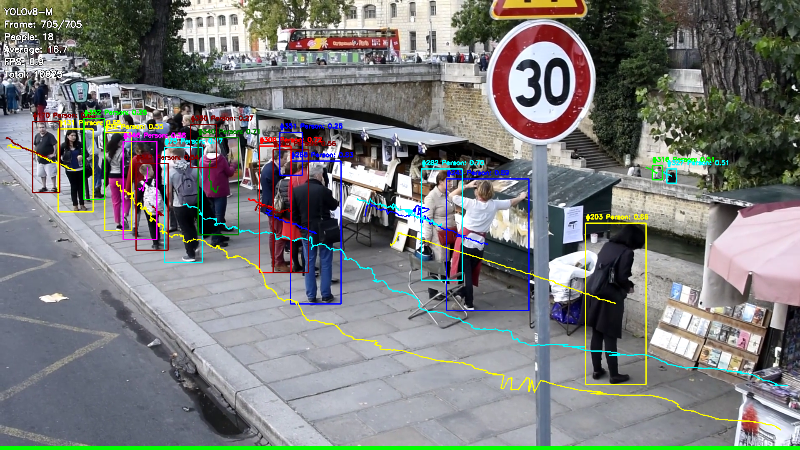

In [5]:
def main():
    """
    Основная функция запуска детектора людей в толпе.

    Функция выполняет:
    - Установку зависимостей
    - Проверку наличия входного файла
    - Инициализацию детектора
    - Обработку видео
    - Вывод результатов

    Returns:
        None
    """
    print("ТОЧНЫЙ ДЕТЕКТОР ЛЮДЕЙ В ТОЛПЕ")
    print("="*50)

    input_file = 'crowd.mp4'
    output_file = 'crowd_detected.mp4'

    if not os.path.exists(input_file):
        print(f"Файл {input_file} не найден! Загрузите файл crowd.mp4")
        return

    detector = CrowdPeopleDetector(model_size='m')
    print("Запуск детектора...")

    print(f"Обрабатываем файл: {input_file}")
    print(f"Результат будет сохранен в: {output_file}")
    print("Это может занять несколько минут в зависимости от размера видео...")

    detector.process_video(input_file, output_file)

if __name__ == "__main__":
    main()